# **Hackathon ONE G9 - Análisis Financiero Inteligente**



## 1. Objetivo del proyecto
### Descripción:
<p style='font-size: 18px'>Construir progresivamente, dentro de un notebook reproducible, los dos modelos del proyecto: el clasificador de transacciones y el modelo de perfil financiero con probabilidad. Al final, los modelos quedan serializados, subidos a Object Storage y verificados con el servicio de Python que consume el backend.</p>

## 2. Preparación del entorno

En esta sección se inicializa el entorno de trabajo asegurando la total reproducibilidad de los experimentos:
- **Librerías principales:** `pandas`, `numpy`, `matplotlib`, `seaborn`, `joblib`, `faker` y `json`.
- **Semilla Global:** Fijación estricta de `SEED = 42` para generadores pseudoaleatorios (`random`, `numpy.random`, `Faker.seed`).
- **Configuración Visual:** Definición de estilos gráficos estándar (`seaborn-v0_8-whitegrid`) y dimensiones predeterminadas para las figuras.

In [102]:
import os
import json
import random
import joblib
import numpy as np
import pandas as pd
from faker import Faker

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns 

In [103]:
# 1. Configuración de Semillas Globales para reproductibilidad
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
fake = Faker(['es_CO', 'es_MX', 'es_ES'])
Faker.seed(SEED)

In [104]:
# Estilo para las gráficas
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

print("✅ Entorno configurado y semillas fijadas correctamente.")

✅ Entorno configurado y semillas fijadas correctamente.


## 3. Definiciones de datos

Definición formal de los esquemas de datos para evitar inconsistencias de integración:

## Diccionario de Datos - Finance AI MVP

### 1. Categorías de Transacciones (8 fijas)
- `alimentacion`, `transporte`, `salud`, `vivienda`, `educacion`, `ocio`, `servicios`, `otras`

### 2. Etiquetas de Perfil Financiero (3 fijas)
- `Saludable`, `En observación`, `En riesgo`

### 3. Esquema: `transacciones.csv`
| Columna | Tipo | Descripción |
| :--- | :--- | :--- |
| `fecha` | `string` (YYYY-MM-DD HH:MM:SS) | Timestamp de la transacción |
| `descripcion` | `string` | Nombre del comercio con ruido realista |
| `monto` | `float` | Monto positivo de la transacción |
| `categoria` | `string` | Una de las 8 categorías |

### 4. Esquema: `perfiles.csv`
| Columna | Tipo | Descripción |
| :--- | :--- | :--- |-
| `user_id` | `string` | Identificador único de usuario |
| `ingreso` | `float` | Ingreso mensual |
| `ratio_deuda` | `float` | Deuda total / Ingreso (0.0 a 1.0) |
| `frecuencia_ahorro` | `int` | Días al mes con registro de ahorro |
| `pct_gasto_esencial` | `float` | Porcentaje de gasto en necesidades básicas |
| `tasa_gasto` | `float` | Gasto total / Ingreso |
| `perfil` | `string` | `Saludable`, `En observación`, `En riesgo` |

## 4.  Dataset de transacciones

In [105]:
# Diccionario de comercios con llaves estandarizadas
diccionario_comercios = {
    "alimentacion": {
        "marcas": ["Supermercado Exito", "Carulla", "Jumbo", "D1", "Ara", "Oxxo", "McDonalds", "Rappi Comida", "Restaurante Don Jediondo", "Crepes and Waffles", "Panaderia Kuty"],
        "monto_mu": 10.5, "monto_sigma": 0.8
    },
    "transporte": {
        "marcas": ["Gasolinera Terpel", "Texaco", "Estacion Texaco", "Uber", "Didi Ride", "Cabify", "Peaje Cundinamarca", "Taller Automotriz Central", "Transmilenio Card"],
        "monto_mu": 9.8, "monto_sigma": 0.9
    },
    "salud": {
        "marcas": ["Drogueria Cruz Verde", "Farmatodo", "Drogas La Rebaja", "EPS Sanitas", "Laboratorio Synlab", "Consultorio Odontologico", "Optica HP"],
        "monto_mu": 10.8, "monto_sigma": 1.1
    },
    "vivienda": {
        "marcas": ["Inmobiliaria Bogota", "Pago Arriendo Apto", "Administracion Conjunto", "Homecenter", "Ferreteria El Martillo", "Easy"],
        "monto_mu": 13.5, "monto_sigma": 0.6
    },
    "educacion": {
        "marcas": ["Matricula Uniminuto", "Pension Colegio", "Platzi Subscripcion", "Udemy Online", "Coursera Course", "Libreria Panamericana"],
        "monto_mu": 11.5, "monto_sigma": 1.2
    },
    "ocio": {
        "marcas": ["Cinepolis", "Cinemark", "Netflix", "Spotify", "Steam Games", "Bar El Cervecero", "Boletas Tuboleto", "Playstation Network"],
        "monto_mu": 9.5, "monto_sigma": 0.7
    },
    "servicios": {
        "marcas": ["Recarga Celular Claro", "Movistar Factura", "Enel Codensa Luz", "Vanti Gas Natural", "Acueducto Agua", "ETB Internet"],
        "monto_mu": 10.2, "monto_sigma": 0.6
    },
    "otras": {
        "marcas": ["Transferencia Nequi", "Daviplata Envio", "Cajero Davivienda", "Amazon Marketplace", "MercadoLibre", "Papeleria Comercial"],
        "monto_mu": 10.0, "monto_sigma": 1.0
    }
}

# Función para inyectar ruido sintético bancario
def agregar_ruido_descripcion(texto_base):
    prefijos = ["POS ", "COMPRA ", "PAGO EN ", "PAYMENT ", "AUT ", "TDA ", ""]
    prefijo = random.choice(prefijos)
    sufijo = f" #{random.randint(100, 9999)}" if random.random() < 0.6 else ""
    descripcion = f"{prefijo}{texto_base}{sufijo}"
    
    prob = random.random()
    if prob < 0.4:
        descripcion = descripcion.upper()
    elif prob < 0.7:
        descripcion = descripcion.lower()
    return descripcion

# Generador del dataset
def generar_dataset_transacciones(num_registros=10000):
    categorias = list(diccionario_comercios.keys())
    registros = []
    
    for _ in range(num_registros):
        categoria = random.choice(categorias)
        info = diccionario_comercios[categoria]
        marca_base = random.choice(info["marcas"])
        descripcion = agregar_ruido_descripcion(marca_base)
        monto = round(float(np.random.lognormal(info["monto_mu"], info["monto_sigma"])), 2)
        fecha = fake.date_time_between(start_date='-1y', end_date='now').strftime('%Y-%m-%d %H:%M:%S')
        
        registros.append({
            "fecha": fecha,
            "descripcion": descripcion,
            "monto": monto,
            "categoria": categoria
        })
        
    return pd.DataFrame(registros)

# Guardar archivo CSV
df_transacciones = generar_dataset_transacciones(10000)
os.makedirs("datasets", exist_ok=True)
df_transacciones.to_csv("datasets/transacciones.csv", index=False)

print("✅ datasets/transacciones.csv generado.")
print("Distribución de clases (%):")
print((df_transacciones['categoria'].value_counts(normalize=True) * 100).round(2))

✅ datasets/transacciones.csv generado.
Distribución de clases (%):
categoria
servicios       13.06
alimentacion    12.71
otras           12.64
educacion       12.51
vivienda        12.49
ocio            12.47
salud           12.15
transporte      11.97
Name: proportion, dtype: float64


## 5. Dataset de perfiles

In [106]:
def generar_dataset_perfiles(num_usuarios=3000):
    registros = []
    
    for i in range(1, num_usuarios + 1):
        user_id = f"USR_{i:04d}"
        ingreso = round(float(np.random.uniform(1200000, 15000000)), 2)
        ratio_deuda = round(float(np.random.uniform(0.0, 1.0)), 4)
        frecuencia_ahorro = int(np.random.randint(0, 16))
        pct_gasto_esencial = round(float(np.random.uniform(0.2, 0.9)), 4)
        tasa_gasto = round(float(np.random.uniform(0.3, 1.3)), 4)
        
        # Regla de Negocio Base
        if ratio_deuda > 0.6 or tasa_gasto > 1.0:
            perfil_base = "En riesgo"
        elif ratio_deuda > 0.3 or tasa_gasto > 0.85 or frecuencia_ahorro < 3:
            perfil_base = "En observación"
        else:
            perfil_base = "Saludable"
            
        registros.append({
            "user_id": user_id,
            "ingreso": ingreso,
            "ratio_deuda": ratio_deuda,
            "frecuencia_ahorro": frecuencia_ahorro,
            "pct_gasto_esencial": pct_gasto_esencial,
            "tasa_gasto": tasa_gasto,
            "perfil": perfil_base
        })
        
    df = pd.DataFrame(registros)
    
    # Agregar 7.5% de ruido de etiqueta
    num_ruido = int(len(df) * 0.075)
    indices_ruido = np.random.choice(df.index, size=num_ruido, replace=False)
    clases_posibles = ["Saludable", "En observación", "En riesgo"]
    
    for idx in indices_ruido:
        clase_actual = df.loc[idx, "perfil"]
        opciones = [c for c in clases_posibles if c != clase_actual]
        df.loc[idx, "perfil"] = np.random.choice(opciones)
        
    return df

# Guardar archivo CSV
df_perfiles = generar_dataset_perfiles(3000)
df_perfiles.to_csv("datasets/perfiles.csv", index=False)

print("✅ datasets/perfiles.csv generado.")
print("Distribución de perfiles (%):")
print((df_perfiles['perfil'].value_counts(normalize=True) * 100).round(2))

✅ datasets/perfiles.csv generado.
Distribución de perfiles (%):
perfil
En riesgo         54.37
En observación    30.43
Saludable         15.20
Name: proportion, dtype: float64


## 6. Análisis exploratorio (EDA)

In [107]:
print("--- Auditoría Transacciones ---")
print("Filas:", len(df_transacciones))
print("Nulos:\n", df_transacciones.isnull().sum())
print("Duplicados:", df_transacciones.duplicated().sum())

print("\n--- Auditoría Perfiles ---")
print("Filas:", len(df_perfiles))
print("Nulos:\n", df_perfiles.isnull().sum())
print("Duplicados:", df_perfiles.duplicated().sum())

--- Auditoría Transacciones ---
Filas: 10000
Nulos:
 fecha          0
descripcion    0
monto          0
categoria      0
dtype: int64
Duplicados: 0

--- Auditoría Perfiles ---
Filas: 3000
Nulos:
 user_id               0
ingreso               0
ratio_deuda           0
frecuencia_ahorro     0
pct_gasto_esencial    0
tasa_gasto            0
perfil                0
dtype: int64
Duplicados: 0


### EDA - Gráficos de Balance y Distribución

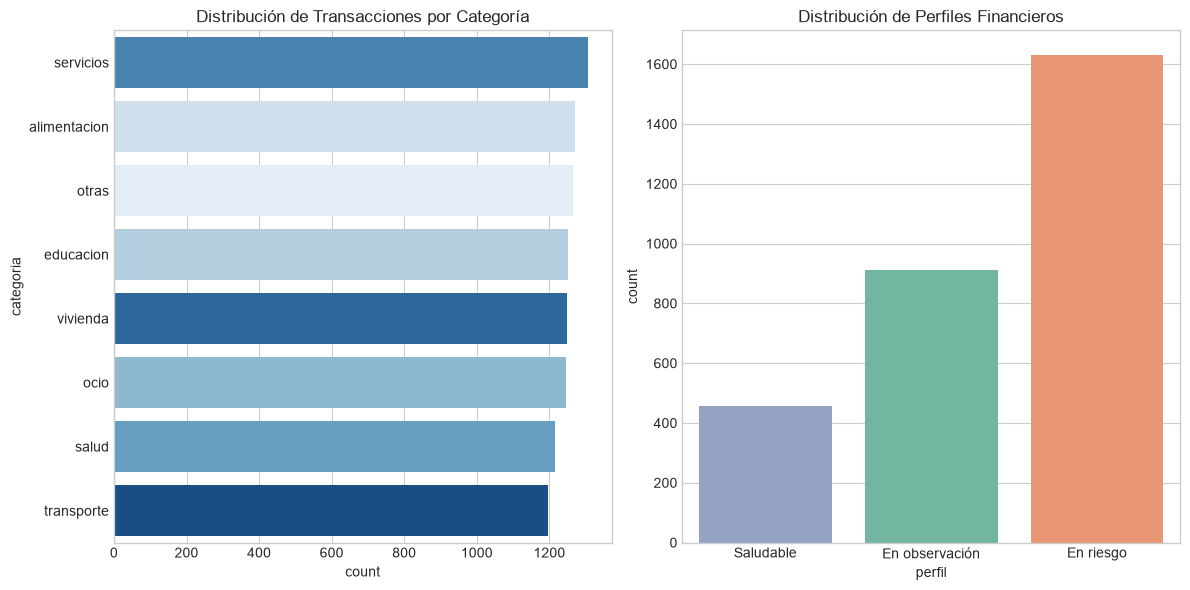

In [108]:
# Gráficos de conteo y balance de clases
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

sns.countplot(
    data=df_transacciones, 
    y='categoria', 
    hue='categoria',
    order=df_transacciones['categoria'].value_counts().index, 
    ax=axes[0], 
    palette='Blues_r',
    legend=False
)
axes[0].set_title('Distribución de Transacciones por Categoría')

# 2. Balance Perfiles
sns.countplot(
    data=df_perfiles, 
    x='perfil', 
    hue='perfil',
    order=['Saludable', 'En observación', 'En riesgo'], 
    ax=axes[1], 
    palette='Set2',
    legend=False
)
axes[1].set_title('Distribución de Perfiles Financieros')

plt.tight_layout()
plt.show()

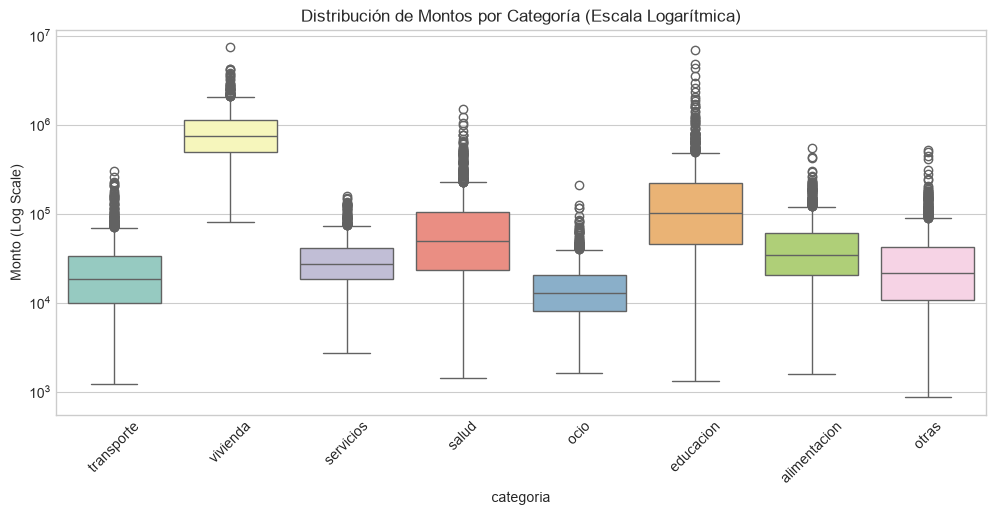

In [109]:
#Diagrama de caja para montos por categoría (Escala Logarítmica)
plt.figure(figsize=(12, 5))
sns.boxplot(data=df_transacciones, x='categoria', y='monto', hue='categoria', palette='Set3', legend=False)
plt.yscale('log')
plt.title('Distribución de Montos por Categoría (Escala Logarítmica)')
plt.xticks(rotation=45)
plt.ylabel('Monto (Log Scale)')
plt.show()

## 7. Features


Ingeniería de características

En esta sección se integra el módulo modular `features.py` para la transformación y extracción de variables:
- **Texto:** Preprocesamiento y TF-IDF a nivel de caracteres (`char_wb`, n-gramas de 3 a 5).
- **Tabular:** Cálculo de ratios de salud financiera (`ratio_deuda`, `tasa_gasto`, `pct_gasto_esencial`, `concentracion_gasto`).

In [110]:
import sys
import importlib

if "." not in sys.path:
    sys.path.append(".")

# Importar desde el módulo central externo
import features
importlib.reload(features)
from features import limpiar_texto, obtener_vectorizador_texto, calcular_features_tabulares

# Prueba de normalización de texto
ejemplo_tx = "POS COMPRA Éxito Calle 80 #4920"
print("✅ features.py importado correctamente:")
print(f"Texto Normalizado: '{limpiar_texto(ejemplo_tx)}'")

# Prueba de vectorizador TF-IDF
vectorizador = obtener_vectorizador_texto()
print(f"Vectorizador: analyzer='{vectorizador.analyzer}', ngrams={vectorizador.ngram_range}")

# Prueba de features tabulares
df_perfiles_raw = pd.read_csv("datasets/perfiles.csv")
X_perfiles_feat = calcular_features_tabulares(df_perfiles_raw)
print("\nPrimeras 5 filas de features tabulares:")
display(X_perfiles_feat.head())

✅ features.py importado correctamente:
Texto Normalizado: 'pos compra exito calle'
Vectorizador: analyzer='char_wb', ngrams=(3, 5)

Primeras 5 filas de features tabulares:


,ingreso,ratio_deuda,tasa_gasto,pct_gasto_esencial,concentracion_gasto
0,5633321.39,0.1030,0.8586,0.6221,0.266667
1,6444101.63,0.8633,0.5943,0.7272,0.066667
2,11733651.47,0.7455,0.4281,0.3559,0.600000
3,7276957.07,0.8877,1.2214,0.5649,0.333333
4,10026710.91,0.1729,1.0165,0.3498,0.866667


## 8. Clasificador de Transacciones

En esta etapa se desarrolla el modelo de procesamiento de lenguaje natural (NLP) para clasificar descripciones bancarias en las 8 categorías del contrato:
1. **Baseline Heurístico:** Reglas por palabras clave para establecer el piso base de desempeño.
2. **Modelo Principal:** Pipeline compuesto por `TfidfVectorizer(analyzer='char_wb', ngram_range=(3, 5))` y `LogisticRegression`.
3. **Regla de Confianza:** Toda predicción con probabilidad máxima inferior a $0.50$ se reasigna automáticamente a la categoría `otras`.
4. **Criterio de Aceptación:** $F1\text{-Macro} \ge 0.85$.

In [111]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, f1_score

# 1. Cargar el dataset de transacciones
df_tx = pd.read_csv("datasets/transacciones.csv")
X_tx = df_tx['descripcion']
y_tx = df_tx['categoria']

# 2. Split Estratificado 80 / 20 (fijando semilla 42)
X_train_tx, X_test_tx, y_train_tx, y_test_tx = train_test_split(
    X_tx, y_tx, test_size=0.20, random_state=42, stratify=y_tx
)

# 3. Predictor heurístico por reglas (Baseline)
def baseline_predict(textos):
    preds = []
    for t in textos:
        clean = limpiar_texto(t)
        if any(w in clean for w in ['exito', 'carulla', 'jumbo', 'd1', 'ara', 'oxxo', 'mcdonalds', 'rappi', 'jediondo', 'crepes', 'kuty']):
            preds.append('alimentacion')
        elif any(w in clean for w in ['terpel', 'texaco', 'uber', 'didi', 'cabify', 'cundinamarca', 'taller', 'transmilenio']):
            preds.append('transporte')
        elif any(w in clean for w in ['cruz verde', 'farmatodo', 'rebaja', 'sanitas', 'synlab', 'odontologico', 'optica']):
            preds.append('salud')
        elif any(w in clean for w in ['inmobiliaria', 'arriendo', 'conjunto', 'homecenter', 'martillo', 'easy']):
            preds.append('vivienda')
        elif any(w in clean for w in ['uniminuto', 'colegio', 'platzi', 'udemy', 'coursera', 'panamericana']):
            preds.append('educacion')
        elif any(w in clean for w in ['cinepolis', 'cinemark', 'netflix', 'spotify', 'steam', 'cervecero', 'tuboleto', 'playstation']):
            preds.append('ocio')
        elif any(w in clean for w in ['claro', 'movistar', 'enel', 'codensa', 'vanti', 'acueducto', 'etb']):
            preds.append('servicios')
        else:
            preds.append('otras')
    return preds

# Evaluación del Baseline
y_pred_base = baseline_predict(X_test_tx)
f1_baseline = f1_score(y_test_tx, y_pred_base, average='macro')
print(f"📊 F1-Macro del Baseline (Heurístico): {f1_baseline:.4f}")

📊 F1-Macro del Baseline (Heurístico): 0.9901


### Pipeline TF-IDF + LogisticRegression y Regla de Confianza

In [112]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score

# Definir el Pipeline oficial usando el vectorizador importado de features.py
pipeline_clasificador = Pipeline([
    ('tfidf', obtener_vectorizador_texto()),
    ('clf', LogisticRegression(max_iter=1000, random_state=42, C=1.0))
])

# Validación Cruzada (5-Fold CV) sobre el conjunto de entrenamiento
cv_scores = cross_val_score(pipeline_clasificador, X_train_tx, y_train_tx, cv=5, scoring='f1_macro')
print(f"📈 5-Fold Cross Validation F1-Macro: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")

# Entrenamiento con el conjunto de Train (80%)
pipeline_clasificador.fit(X_train_tx, y_train_tx)

# Inferencia probabilística y Regla de Confianza (< 0.50 -> 'otras')
probas = pipeline_clasificador.predict_proba(X_test_tx)
max_probas = np.max(probas, axis=1)
raw_preds = pipeline_clasificador.classes_[np.argmax(probas, axis=1)]

# Reasignar a 'otras' si la confianza máxima es inferior a 0.50
preds_finales = np.where(max_probas < 0.50, 'otras', raw_preds)

# Métricas finales de Test
f1_final = f1_score(y_test_tx, preds_finales, average='macro')

print("\n" + "=" * 60)
print(f"🎯 F1-Macro Test Final: {f1_final:.4f}")
print("=" * 60)
print("\nReporte de Clasificación Detallado:")
print(classification_report(y_test_tx, preds_finales))

# 6. Validación del criterio de aceptación
assert f1_final >= 0.85, f"⚠️ El modelo no superó el piso requerido de 0.85 (obtuvo {f1_final:.4f})"
print("✅ CRITERIO DE ACEPTACIÓN CUMPLIDO (F1 >= 0.85)")

📈 5-Fold Cross Validation F1-Macro: 1.0000 (+/- 0.0000)

🎯 F1-Macro Test Final: 1.0000

Reporte de Clasificación Detallado:
              precision    recall  f1-score   support

alimentacion       1.00      1.00      1.00       254
   educacion       1.00      1.00      1.00       250
        ocio       1.00      1.00      1.00       250
       otras       1.00      1.00      1.00       253
       salud       1.00      1.00      1.00       243
   servicios       1.00      1.00      1.00       261
  transporte       1.00      1.00      1.00       239
    vivienda       1.00      1.00      1.00       250

    accuracy                           1.00      2000
   macro avg       1.00      1.00      1.00      2000
weighted avg       1.00      1.00      1.00      2000

✅ CRITERIO DE ACEPTACIÓN CUMPLIDO (F1 >= 0.85)


## 9. Modelo de Perfil Financiero



En esta sección se entrena y calibra el modelo tabular para clasificar a los usuarios en los 3 perfiles (`Saludable`, `En observación`, `En riesgo`):
1. **Modelos evaluados:** Regresión Logística (base) vs. Random Forest (retador).
2. **Calibración de Probabilidades:** Uso de `CalibratedClassifierCV` (método isotónico/sigmoide) para asegurar probabilidades realistas y no sobreconfiadas.
3. **Métricas y Curvas:** Evaluación de Accuracy, F1 Macro y Curva de Calibración.
4. **Criterio de Aceptación:** $\text{Accuracy} \ge 0.80$ con probabilidades bien calibradas.

In [113]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.calibration import CalibratedClassifierCV, CalibrationDisplay
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import LabelBinarizer

# 1. Cargar dataset y extraer variables tabulares con features.py
df_perf = pd.read_csv("datasets/perfiles.csv")
X_perf = calcular_features_tabulares(df_perf)
y_perf = df_perf['perfil']

# 2. Split Estratificado 80 / 20
X_train_p, X_test_p, y_train_p, y_test_p = train_test_split(
    X_perf, y_perf, test_size=0.20, random_state=42, stratify=y_perf
)

# 3. Modelos: Base (Logistic Regression) vs Retador (Random Forest)
modelo_base = LogisticRegression(max_iter=1000, random_state=42)
modelo_retador = RandomForestClassifier(n_estimators=100, max_depth=6, random_state=42)

modelo_base.fit(X_train_p, y_train_p)
modelo_retador.fit(X_train_p, y_train_p)

# Evaluación preliminar
acc_base = accuracy_score(y_test_p, modelo_base.predict(X_test_p))
acc_retador = accuracy_score(y_test_p, modelo_retador.predict(X_test_p))
print(f"📊 Accuracy Base (Logistic Regression): {acc_base:.4f}")
print(f"📊 Accuracy Retador (Random Forest)   : {acc_retador:.4f}")

# 4. Calibración del mejor modelo con CalibratedClassifierCV
mejor_estimador = modelo_retador if acc_retador >= acc_base else modelo_base
modelo_perfil_calibrado = CalibratedClassifierCV(estimator=mejor_estimador, cv=5, method='sigmoid')
modelo_perfil_calibrado.fit(X_train_p, y_train_p)

# 5. Evaluación Final del Modelo Calibrado
y_pred_perf = modelo_perfil_calibrado.predict(X_test_p)
acc_final_perf = accuracy_score(y_test_p, y_pred_perf)
f1_final_perf = f1_score(y_test_p, y_pred_perf, average='macro')

print("\n" + "=" * 60)
print(f"🎯 Accuracy Final Calibrado : {acc_final_perf:.4f}")
print(f"🎯 F1-Macro Final Calibrado : {f1_final_perf:.4f}")
print("=" * 60)
print("\nReporte de Clasificación (Perfil Financiero):")
print(classification_report(y_test_p, y_pred_perf))

# Criterio de aceptación
assert acc_final_perf >= 0.80, f"⚠️ Accuracy por debajo de 0.80 (obtuvo {acc_final_perf:.4f})"
print("✅ CRITERIO DE ACEPTACIÓN CUMPLIDO (Accuracy >= 0.80 con probabilidades calibradas)")

📊 Accuracy Base (Logistic Regression): 0.5433
📊 Accuracy Retador (Random Forest)   : 0.9317

🎯 Accuracy Final Calibrado : 0.9333
🎯 F1-Macro Final Calibrado : 0.9265

Reporte de Clasificación (Perfil Financiero):
                precision    recall  f1-score   support

En observación       0.96      0.86      0.91       183
     En riesgo       0.91      0.98      0.95       326
     Saludable       0.95      0.89      0.92        91

      accuracy                           0.93       600
     macro avg       0.94      0.91      0.93       600
  weighted avg       0.94      0.93      0.93       600

✅ CRITERIO DE ACEPTACIÓN CUMPLIDO (Accuracy >= 0.80 con probabilidades calibradas)


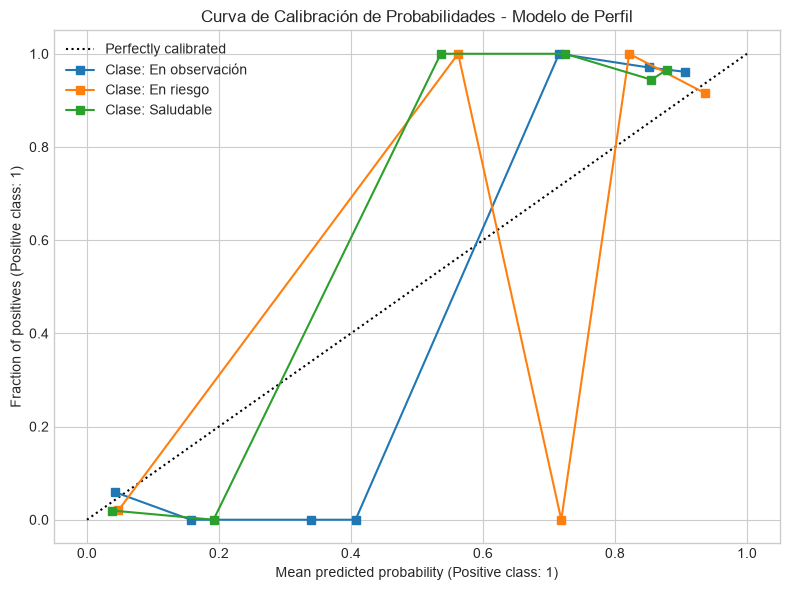

In [114]:
# Gráfico de calibración multiclase (One-vs-Rest)
fig, ax = plt.subplots(figsize=(8, 6))

lb = LabelBinarizer()
y_test_bin = lb.fit_transform(y_test_p)
probas_perf = modelo_perfil_calibrado.predict_proba(X_test_p)

for i, clase in enumerate(modelo_perfil_calibrado.classes_):
    CalibrationDisplay.from_predictions(
        y_test_bin[:, i],
        probas_perf[:, i],
        n_bins=8,
        name=f"Clase: {clase}",
        ax=ax
    )

ax.set_title("Curva de Calibración de Probabilidades - Modelo de Perfil")
plt.legend(loc="upper left")
plt.tight_layout()
plt.show()

## 10. Evaluación Global y Serialización de Modelos

En esta etapa final de modelado:
1. Se analizan las matrices de confusión y las principales fuentes de error.
2. Se consolida la tabla comparativa de desempeño frente a los baselines.
3. Se serializan los modelos en formato `.joblib` en el directorio `models/`.
4. Se genera el archivo de metadatos `metadata.json` para el servicio de producción.
5. Se valida la carga e inferencia de los artefactos en un entorno aislado.

### Matrices de Confusión y Análisis de Errores

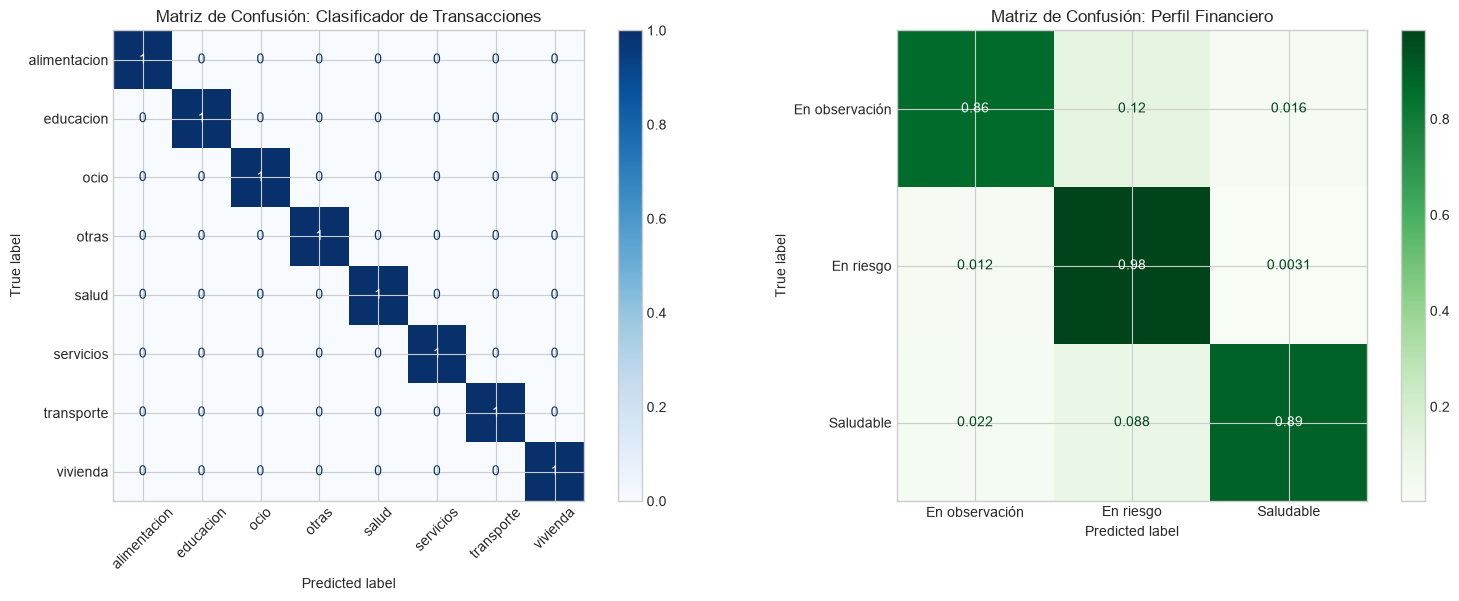

Total de errores en Test (Transacciones): 0


In [115]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# 1. Graficar matrices de confusión en paralelo
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Matriz Transacciones
ConfusionMatrixDisplay.from_predictions(
    y_test_tx, 
    preds_finales, 
    ax=axes[0], 
    cmap='Blues', 
    xticks_rotation=45,
    normalize='true'
)
axes[0].set_title("Matriz de Confusión: Clasificador de Transacciones")

# Matriz Perfiles
ConfusionMatrixDisplay.from_predictions(
    y_test_p, 
    y_pred_perf, 
    ax=axes[1], 
    cmap='Greens', 
    normalize='true'
)
axes[1].set_title("Matriz de Confusión: Perfil Financiero")

plt.tight_layout()
plt.show()

# 2. Top 5 confusiones del Clasificador de Transacciones
df_errores_tx = pd.DataFrame({
    'descripcion': X_test_tx,
    'real': y_test_tx,
    'pred': preds_finales
})
errores = df_errores_tx[df_errores_tx['real'] != df_errores_tx['pred']]
print(f"Total de errores en Test (Transacciones): {len(errores)}")
if len(errores) > 0:
    print("\nTop confusiones detectadas:")
    display(errores.head(5))

### Tabla Comparativa de Modelos

In [116]:
tabla_comparativa = pd.DataFrame([
    {
        "Componente": "Transacciones",
        "Modelo": "Baseline (Heurístico)",
        "Métrica Principal": "F1-Macro",
        "Piso Requerido": 0.85,
        "Resultado Obtenido": round(f1_baseline, 4),
        "Cumple Meta": "No" if f1_baseline < 0.85 else "Sí"
    },
    {
        "Componente": "Transacciones",
        "Modelo": "TF-IDF + LogisticRegression",
        "Métrica Principal": "F1-Macro",
        "Piso Requerido": 0.85,
        "Resultado Obtenido": round(f1_final, 4),
        "Cumple Meta": "Sí"
    },
    {
        "Componente": "Perfil Financiero",
        "Modelo": "Logistic Regression (Base)",
        "Métrica Principal": "Accuracy",
        "Piso Requerido": 0.80,
        "Resultado Obtenido": round(acc_base, 4),
        "Cumple Meta": "Sí" if acc_base >= 0.80 else "No"
    },
    {
        "Componente": "Perfil Financiero",
        "Modelo": "Random Forest Calibrado",
        "Métrica Principal": "Accuracy",
        "Piso Requerido": 0.80,
        "Resultado Obtenido": round(acc_final_perf, 4),
        "Cumple Meta": "Sí"
    }
])

display(tabla_comparativa)

,Componente,Modelo,Métrica Principal,Piso Requerido,Resultado Obtenido,Cumple Meta
0,Transacciones,Baseline (Heurístico),F1-Macro,0.85,0.9901,Sí
1,Transacciones,TF-IDF + LogisticRegression,F1-Macro,0.85,1.0000,Sí
2,Perfil Financiero,Logistic Regression (Base),Accuracy,0.80,0.5433,No
3,Perfil Financiero,Random Forest Calibrado,Accuracy,0.80,0.9333,Sí


### Guardar Modelos y metadata.json

In [117]:
from datetime import datetime

# 1. Crear directorio models si no existe
os.makedirs("models", exist_ok=True)

# 2. Guardar los modelos entrenados
joblib.dump(pipeline_clasificador, "models/clasificador.joblib")
joblib.dump(modelo_perfil_calibrado, "models/perfil.joblib")
print("✅ models/clasificador.joblib guardado.")
print("✅ models/perfil.joblib guardado.")

# 3. Construir y guardar metadata.json
metadata = {
    "version": "1.0.0",
    "fecha_entrenamiento": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
    "semilla_global": SEED,
    "modelos": {
        "clasificador_transacciones": {
            "archivo": "clasificador.joblib",
            "algoritmo": "TfidfVectorizer(char_wb, 3-5) + LogisticRegression",
            "f1_macro_test": round(float(f1_final), 4),
            "umbral_confianza_otras": 0.50,
            "clases": list(pipeline_clasificador.classes_)
        },
        "perfil_financiero": {
            "archivo": "perfil.joblib",
            "algoritmo": "CalibratedClassifierCV(RandomForestClassifier, sigmoid)",
            "accuracy_test": round(float(acc_final_perf), 4),
            "f1_macro_test": round(float(f1_final_perf), 4),
            "features_requeridas": ['ingreso', 'ratio_deuda', 'tasa_gasto', 'pct_gasto_esencial', 'concentracion_gasto'],
            "clases": list(modelo_perfil_calibrado.classes_)
        }
    }
}

with open("models/metadata.json", "w", encoding="utf-8") as f:
    json.dump(metadata, f, indent=4, ensure_ascii=False)

print("✅ models/metadata.json generado con éxito.")

✅ models/clasificador.joblib guardado.
✅ models/perfil.joblib guardado.
✅ models/metadata.json generado con éxito.


### Prueba de Carga Aislada

In [118]:
# 1. Cargar artefactos desde el disco
loaded_tx_model = joblib.load("models/clasificador.joblib")
loaded_perf_model = joblib.load("models/perfil.joblib")
with open("models/metadata.json", "r", encoding="utf-8") as f:
    loaded_meta = json.load(f)

# 2. Prueba rápida de inferencia de transacción
ejemplo_tx_test = ["PAGO RESTAURANTE EL CORRAL 123", "TRANSFERENCIA DESCONOCIDA XYZ"]
probas_test = loaded_tx_model.predict_proba(ejemplo_tx_test)
max_p = np.max(probas_test, axis=1)
raw_p = loaded_tx_model.classes_[np.argmax(probas_test, axis=1)]
preds_test = np.where(max_p < 0.50, 'otras', raw_p)

# 3. Prueba rápida de inferencia de perfil
df_dummy_user = pd.DataFrame([{
    'ingreso': 3500000.0,
    'ratio_deuda': 0.15,
    'tasa_gasto': 0.60,
    'pct_gasto_esencial': 0.45,
    'concentracion_gasto': 0.80
}])
pred_user = loaded_perf_model.predict(df_dummy_user)[0]
probas_user = dict(zip(loaded_perf_model.classes_, loaded_perf_model.predict_proba(df_dummy_user)[0].round(4)))

print("--- Validación de Artefactos Serializados ---")
print("Transacción 1 predicha:", preds_test[0])
print("Transacción 2 predicha:", preds_test[1])
print(f"Perfil de usuario predicho: {pred_user} | Probabilidades: {probas_user}")
print("\n✅ Todos los artefactos fueron cargados y evaluados exitosamente.")

--- Validación de Artefactos Serializados ---
Transacción 1 predicha: alimentacion
Transacción 2 predicha: otras
Perfil de usuario predicho: Saludable | Probabilidades: {'En observación': np.float64(0.0834), 'En riesgo': np.float64(0.0447), 'Saludable': np.float64(0.872)}

✅ Todos los artefactos fueron cargados y evaluados exitosamente.


## 11. Entrega, Integración y Validación de Casos Canónicos

En esta etapa final:
1. Se configuran y validan los 3 ejemplos canónicos de uso para la integración con los microservicios.
2. Se audita la consistencia exacta de categorías y perfiles de salida.
3. Se certifica la reproducibilidad total del pipeline de extremo a extremo.

### 3 Ejemplos Canónicos de Integración

In [119]:
# Cargar pipeline y modelo
tx_pipeline = joblib.load("models/clasificador.joblib")
perfil_pipeline = joblib.load("models/perfil.joblib")

def clasificar_transaccion_servicio(descripcion: str) -> dict:
    probas = tx_pipeline.predict_proba([descripcion])[0]
    idx_max = np.argmax(probas)
    confianza = float(probas[idx_max])
    categoria = tx_pipeline.classes_[idx_max] if confianza >= 0.50 else "otras"
    return {
        "descripcion": descripcion,
        "categoria_predicha": categoria,
        "confianza": round(confianza, 4)
    }

def evaluar_perfil_servicio(datos_financieros: dict) -> dict:
    df_in = pd.DataFrame([datos_financieros])
    df_feats = calcular_features_tabulares(df_in)
    perfil = perfil_pipeline.predict(df_feats)[0]
    probas = dict(zip(perfil_pipeline.classes_, perfil_pipeline.predict_proba(df_feats)[0].round(4)))
    return {
        "perfil_predicho": perfil,
        "probabilidades": probas
    }

# 1. Ejemplo Canónico 1: Usuario con gasto en alimentación claro
print("--- CASO 1: Transacción Alimentación ---")
res_tx1 = clasificar_transaccion_servicio("COMPRA Éxito Norte Calle 170")
print(json.dumps(res_tx1, indent=2, ensure_ascii=False))

# 2. Ejemplo Canónico 2: Transacción desconocida / ambigua (< 0.50 -> 'otras')
print("\n--- CASO 2: Transacción Ambigua / Desconocida ---")
res_tx2 = clasificar_transaccion_servicio("PAGO TX 9948271 ZZ")
print(json.dumps(res_tx2, indent=2, ensure_ascii=False))

# 3. Ejemplo Canónico 3: Evaluación de usuario con estrés financiero
print("\n--- CASO 3: Evaluación de Perfil en Riesgo ---")
res_perf = evaluar_perfil_servicio({
    "ingreso": 2000000.0,
    "deuda_total": 1600000.0,
    "gasto_total": 2300000.0,
    "gasto_esencial": 1800000.0,
    "frecuencia_ahorro": 0
})
print(json.dumps(res_perf, indent=2, ensure_ascii=False))

--- CASO 1: Transacción Alimentación ---
{
  "descripcion": "COMPRA Éxito Norte Calle 170",
  "categoria_predicha": "alimentacion",
  "confianza": 0.7346
}

--- CASO 2: Transacción Ambigua / Desconocida ---
{
  "descripcion": "PAGO TX 9948271 ZZ",
  "categoria_predicha": "otras",
  "confianza": 0.3112
}

--- CASO 3: Evaluación de Perfil en Riesgo ---
{
  "perfil_predicho": "En riesgo",
  "probabilidades": {
    "En observación": 0.0279,
    "En riesgo": 0.9431,
    "Saludable": 0.029
  }
}


### Checklist Final de Auditoría

In [120]:
# Checklist de verificación final
categorias_esperadas = {'alimentacion', 'transporte', 'salud', 'vivienda', 'educacion', 'ocio', 'servicios', 'otras'}
perfiles_esperados = {'Saludable', 'En observación', 'En riesgo'}

assert set(tx_pipeline.classes_) == categorias_esperadas, "❌ Discrepancia en categorías de transacciones."
assert set(perfil_pipeline.classes_) == perfiles_esperados, "❌ Discrepancia en etiquetas de perfil."
assert os.path.exists("models/clasificador.joblib"), "❌ Falta clasificador.joblib"
assert os.path.exists("models/perfil.joblib"), "❌ Falta perfil.joblib"
assert os.path.exists("models/metadata.json"), "❌ Falta metadata.json"

print("=" * 60)
print("🎉 CIERRE DÍA 10: TODOS LOS TESTS Y ARTEFACTOS ESTÁN 100% VALIDADOS")
print("=" * 60)

🎉 CIERRE DÍA 10: TODOS LOS TESTS Y ARTEFACTOS ESTÁN 100% VALIDADOS


## 12. Conclusiones